In [3]:
# 从 BCG 分类结果中筛选明星产品，并按 Description 关键词分类、销量降序排列
import pandas as pd
import os
import re
from collections import OrderedDict

BCG_FILE = './bcg_product_classification.xlsx'
star_products = pd.read_excel(BCG_FILE)

if 'BCG类型' not in star_products.columns:
    raise KeyError('输入文件必须包含 BCG类型 列')

if 'Description' not in star_products.columns:
    raise KeyError('输入文件必须包含 Description 列')

# 依据 BCG 类型筛选 Star 产品
star_products = star_products[star_products['BCG类型'].eq('Star')].copy()
print(f'筛选出的明星产品数量：{len(star_products)}')

# 兼容不同文件中的销量列名称
sales_column_candidates = ['总销量', '销量', 'Quantity', 'Sales']
sales_column = next(
    (column for column in sales_column_candidates if column in star_products.columns),
    None
)
if sales_column is None:
    raise KeyError(f'未找到销量列，请确认列名为以下之一：{sales_column_candidates}')

# 关键词按优先级匹配：同一商品命中多个关键词时，归入排在前面的类目
category_keywords = OrderedDict([
    ('圣诞节用品', [
        'CHRISTMAS', 'XMAS', 'SANTA', 'REINDEER', 'SNOWMAN', 'ANGEL',
        'STOCKING', 'BAUBLE', 'ORNAMENT', 'TREE', 'T-LIGHT HOLDER',
        'SLEIGH', 'ADVENT', 'NOEL', 'SNOWY VILLAGE'
    ]),
    ('派对用品', [
        'PARTY', 'BALLOON', 'BIRTHDAY', 'CONFETTI', 'STREAMER', 'CUP',
        'PLATE', 'NAPKIN', 'PAPER HAT', 'CAKE', 'POPCORN', 'BUBBLE',
        'GUMBALL', 'COCKTAIL', 'HONEYCOMB FAN', 'GARLAND', 'MATCHES'
    ]),
    ('厨房与餐具', [
        'MUG', 'CUP', 'BOWL', 'PLATE', 'SPOON', 'FORK', 'KNIFE', 'KITCHEN',
        'TEA', 'COFFEE', 'JAM', 'TRAY', 'LUNCH', 'COASTER', 'APRON',
        'PANTRY', 'MOULD', 'BAKING', 'COOKIE CUTTER', 'LOAF', 'BEAKER',
        'WASHING UP', 'ROLLING PIN', 'SUGAR TONGS', 'FRYING PAN',
        'CHOPPING BOARD', 'JUG', 'PLACEMAT', 'BREAKFAST SET', 'FLANNEL'
    ]),
    ('家居装饰', [
        'DECORATION', 'DECORATIVE', 'FRAME', 'MIRROR', 'CUSHION', 'VASE',
        'SIGN', 'WALL', 'HANGING', 'HEART', 'STAR', 'CANDLE', 'LIGHT',
        'HOLDER', 'CLOCK', 'COAT RACK', 'DOORMAT', 'HOT WATER BOTTLE',
        'HAND WARMER', 'CABINET', 'DRAWER', 'KNOB', 'HOOK', 'DRESSING TABLE',
        'TRINKET POT', 'INCENSE', 'DOOR HANGER', 'BLACKBOARD', 'BOTTLE',
        'LAMPSHADE', 'WREATH', 'DOORSTOP', 'SHELF', 'FOOT STOOL',
        'MONEY BANK', 'TREASURE CHEST', 'KEY CABINET', 'KEY HOLDER',
        'LETTER HOLDER', 'EGG WARMER', 'D.O.F. GLASS', 'WATER BOTTLE',
        'PAINTED METAL PEARS', 'PIGGY BANK', 'PORCELAIN ROSE'
    ]),
    ('礼品与纪念品', [
        'GIFT', 'SOUVENIR', 'MEMO', 'MAGNET', 'KEYRING', 'BOX', 'BAG',
        'WRAP', 'CARD', 'TAPE', 'SHOPPER', 'RIBBON', 'PURSE', 'JEWELLERY',
        'EARRING', 'CALCULATOR', 'LONDON', 'UNION JACK', 'BICYCLE BELL',
        'MINI BACKPACK'
    ]),
    ('玩具与儿童用品', [
        'TOY', 'DOLL', 'GAME', 'PUZZLE', 'JIGSAW', 'DOMINO', 'CHILDREN',
        'KID', 'BABY', 'TEDDY', 'WOODEN', 'PLAYHOUSE', 'MODELLING CLAY',
        'DRAWING SLATE', 'ROCKING HORSE', 'SKITTLES', 'NAUGHTS',
        'SNAKES', 'BINGO', 'STENCIL CRAFT', 'LOLLY MAKERS', 'RATTLE SNAKE',
        'FELTCRAFT', 'MAGIC DRAWING', 'SPACEBOY', 'BUNNIES', 'DINOSAUR',
        'MINI PAINT SET', 'PAINT YOUR OWN CANVAS'
    ]),
    ('文具用品', [
        'PEN', 'PENCIL', 'NOTEBOOK', 'NOTE BOOK', 'NOTE PAD', 'STATIONERY',
        'RULER', 'ERASER', 'PAPER', 'POSTAGE', 'SCISSOR', 'EXERCISE BOOK',
        'TISSUE', 'STICKER', 'STAMP', 'CHALK', 'SPIRIT LEVEL', 'MANUAL',
        'ALPHABET', 'CALCULATOR'
    ]),
    ('服饰与纺织品', [
        'CLOTH', 'TEXTILE', 'SCARF', 'HAT', 'SOCK', 'APRON', 'TOWEL',
        'BLANKET', 'FABRIC', 'RING', 'PONCHO', 'SOMBRERO', 'UMBRELLA',
        'HAIRBAND', 'PANT', 'SEWING', 'NEEDLE', 'PARASOL', 'BRACELET',
        'POLYESTER FILLER PAD'
    ]),
    ('花园与户外用品', [
        'GARDEN', 'PLANT', 'FLOWER', 'BIRD', 'WATERING', 'OUTDOOR', 'PICNIC',
        'BICYCLE', 'PUNCTURE', 'TORCH', 'SCREWDRIVER', 'SUCTION HOOK'
    ]),
    ('美妆与个人护理', [
        'BATH', 'SOAP', 'BEAUTY', 'COSMETIC', 'MIRROR', 'PERFUME', 'TOILET',
        'LIP GLOSS', 'HAND WARMER','WATER TRANSFER TATTOOS'
    ]),
    ('宠物用品', [
        'PET', 'DOG', 'CAT', 'ANIMAL', 'FEEDER', 'BOWL'
    ]),
    ('收纳与包装', [
        'STORAGE', 'ORGANIZER', 'CONTAINER', 'JAR', 'TIN', 'BASKET',
        'PACKAGING', 'WRAP', 'CASE', 'CABINET', 'CHEST'
    ])
])

compiled_keywords = [
    (category, re.compile('|'.join(re.escape(keyword) for keyword in keywords)))
    for category, keywords in category_keywords.items()
]


def classify_product(description):
    description = str(description).upper()
    for category, pattern in compiled_keywords:
        if pattern.search(description):
            return category
    return '其他'


star_products['商品类目'] = star_products['Description'].apply(classify_product)
star_products[sales_column] = pd.to_numeric(
    star_products[sales_column], errors='coerce'
).fillna(0)
star_products = star_products.sort_values(
    sales_column, ascending=False
).reset_index(drop=True)

# 输出明细和各类目的汇总，均按销量降序排列
category_summary = (
    star_products.groupby('商品类目', as_index=False)
    .agg(商品数量=('Description', 'size'), 总销量=(sales_column, 'sum'))
    .sort_values('总销量', ascending=False)
    .reset_index(drop=True)
)

print('明星产品分类结果（按销量降序）：')
display(star_products[['StockCode', 'Description', '商品类目', sales_column]])
print('\n类目汇总（按总销量降序）：')
display(category_summary)

star_products.to_excel('./star_products_categorized.xlsx', index=False)
category_summary.to_excel('./star_product_category_summary.xlsx', index=False)
print('\n已保存：star_products_categorized.xlsx、star_product_category_summary.xlsx')

筛选出的明星产品数量：992
明星产品分类结果（按销量降序）：


,StockCode,Description,商品类目,总销量
0,23843,"PAPER CRAFT , LITTLE BIRDIE",文具用品,80995
1,22197,POPCORN HOLDER,派对用品,49160
2,85099B,JUMBO BAG RED RETROSPOT,礼品与纪念品,46078
3,84879,ASSORTED COLOUR BIRD ORNAMENT,圣诞节用品,35263
4,23084,RABBIT NIGHT LIGHT,家居装饰,27153
...,...,...,...,...
987,22947,WOODEN ADVENT CALENDAR RED,圣诞节用品,424
988,23598,PAPER BUNTING VINTAGE PARTY,派对用品,420
989,23022,SMALL BONNE JAM JAR T-LIGHT HOLDER,圣诞节用品,416
990,23482,PEARLISED IVORY HEART LARGE,家居装饰,415



类目汇总（按总销量降序）：


,商品类目,商品数量,总销量
0,家居装饰,340,725131
1,礼品与纪念品,140,494964
2,圣诞节用品,149,406988
3,厨房与餐具,109,306578
4,文具用品,72,262055
5,派对用品,64,224286
6,玩具与儿童用品,71,187410
7,收纳与包装,20,59585
8,服饰与纺织品,14,33018
9,美妆与个人护理,5,21533



已保存：star_products_categorized.xlsx、star_product_category_summary.xlsx


# 商品类目分析思路
0. 锁定销量Top3类目及其Top5商品。
1. 基于时间序列分析，检测数据是否存在规律性波动

家居装饰 类目总销量 Top 5 商品：


,StockCode,Description,总销量
0,23084,RABBIT NIGHT LIGHT,27153
1,84946,ANTIQUE SILVER T-LIGHT GLASS,16436
2,21731,RED TOADSTOOL LED NIGHT LIGHT,12863
3,21181,PLEASE ONE PERSON METAL SIGN,11932
4,22998,TRAVEL CARD WALLET KEEP CALM,11645


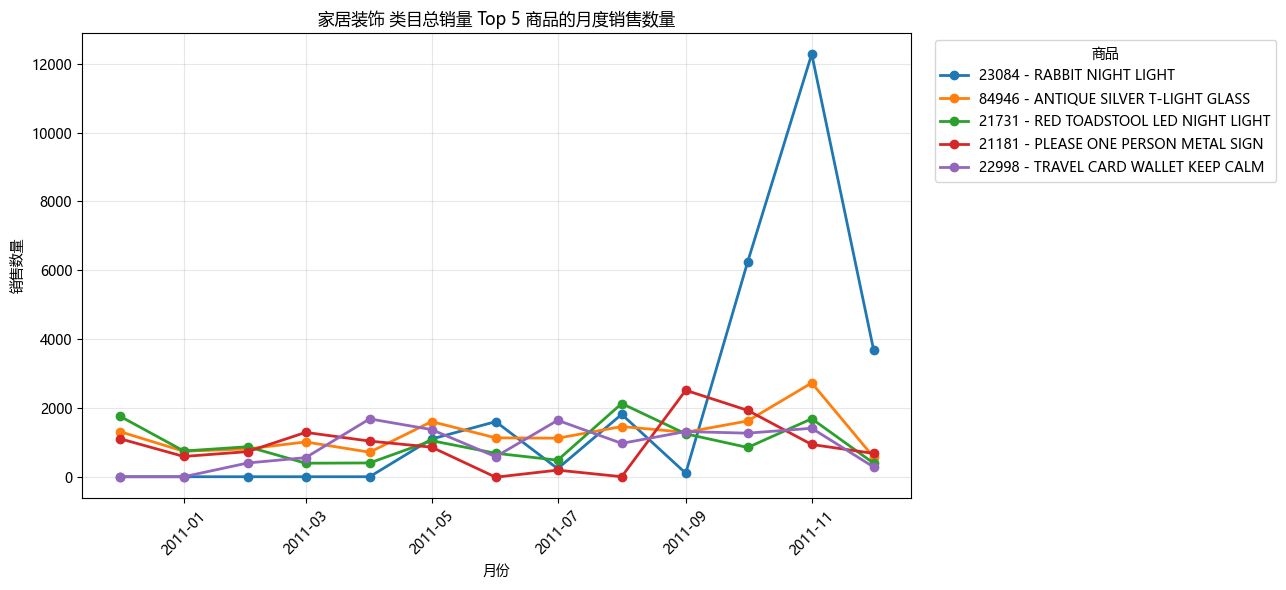

已保存：home_decor_top5_products.xlsx、home_decor_top5_monthly_sales.xlsx


In [7]:
# 分析家居装饰类目下总销量最高的 5 个商品的月度销售数量
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

CATEGORY_FILE = './star_products_categorized.xlsx'
RETAIL_FILE = './Data/Online_Retail_Cleaned.xlsx'
TARGET_CATEGORY = '家居装饰'
TOP_N = 5

categorized_products = pd.read_excel(CATEGORY_FILE)
required_category_columns = {'StockCode', '商品类目'}
missing_category_columns = required_category_columns.difference(categorized_products.columns)
if missing_category_columns:
    raise KeyError(f'分类结果缺少字段：{sorted(missing_category_columns)}')

sales_column_candidates = ['总销量', '销量', 'Quantity', 'Sales']
sales_column = next(
    (column for column in sales_column_candidates if column in categorized_products.columns),
    None
)
if sales_column is None:
    raise KeyError(f'未找到销量列，请确认列名为以下之一：{sales_column_candidates}')

# 统一商品编码和销量格式，只在家居装饰类目内选择总销量最高的商品
categorized_products['StockCode'] = categorized_products['StockCode'].astype(str).str.strip()
categorized_products[sales_column] = pd.to_numeric(
    categorized_products[sales_column], errors='coerce'
).fillna(0)

target_products = categorized_products[
    categorized_products['商品类目'].eq(TARGET_CATEGORY)
].copy()
if target_products.empty:
    raise ValueError(f'未找到商品类目：{TARGET_CATEGORY}')

top_products = (
    target_products.groupby('StockCode', as_index=False)
    .agg(总销量=(sales_column, 'sum'))
    .sort_values('总销量', ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

product_descriptions = (
    target_products[['StockCode', 'Description']]
    .drop_duplicates('StockCode')
    if 'Description' in target_products.columns
    else top_products[['StockCode']].assign(Description='')
)
top_products = top_products.merge(product_descriptions, on='StockCode', how='left')
top_products['商品标签'] = top_products.apply(
    lambda row: f"{row['StockCode']} - {row['Description']}" if row['Description'] else row['StockCode'],
    axis=1
)

retail = pd.read_excel(RETAIL_FILE)
required_retail_columns = {'StockCode', 'Quantity'}
missing_retail_columns = required_retail_columns.difference(retail.columns)
if missing_retail_columns:
    raise KeyError(f'清洗数据缺少字段：{sorted(missing_retail_columns)}')

date_column_candidates = ['InvoiceDate', '销售日期', '日期', 'Date', '交易日期']
date_column = next(
    (column for column in date_column_candidates if column in retail.columns),
    None
)
if date_column is None:
    raise KeyError(f'未找到日期列，请确认列名为以下之一：{date_column_candidates}')

retail['StockCode'] = retail['StockCode'].astype(str).str.strip()
retail['Quantity'] = pd.to_numeric(retail['Quantity'], errors='coerce').fillna(0)
retail[date_column] = pd.to_datetime(retail[date_column], errors='coerce')

# 只保留家居装饰类目中销量最高的 5 个商品，并按月份汇总销售数量
monthly_sales = (
    retail.dropna(subset=[date_column])
    .merge(top_products[['StockCode', '商品标签']], on='StockCode', how='inner')
    .assign(月份=lambda data: data[date_column].dt.to_period('M').dt.to_timestamp())
    .groupby(['月份', 'StockCode', '商品标签'], as_index=False)['Quantity']
    .sum()
    .rename(columns={'Quantity': '月销售数量'})
)

if monthly_sales.empty:
    raise ValueError('家具装饰类目 Top 5 商品在零售明细中没有可用的月度销售记录')

# 补齐所有月份和 Top 5 商品，没有销售记录的月份按 0 计
all_months = pd.date_range(
    monthly_sales['月份'].min(), monthly_sales['月份'].max(), freq='MS'
)
full_index = pd.MultiIndex.from_product(
    [all_months, top_products['StockCode']], names=['月份', 'StockCode']
)
product_labels = top_products.set_index('StockCode')['商品标签']
monthly_sales = (
    monthly_sales.set_index(['月份', 'StockCode'])[['商品标签', '月销售数量']]
    .reindex(full_index)
    .reset_index()
)
monthly_sales['商品标签'] = monthly_sales['StockCode'].map(product_labels)
monthly_sales['月销售数量'] = monthly_sales['月销售数量'].fillna(0)

print(f'{TARGET_CATEGORY} 类目总销量 Top {TOP_N} 商品：')
display(top_products[['StockCode', 'Description', '总销量']])

top_products.to_excel('./home_decor_top5_products.xlsx', index=False)
monthly_sales.to_excel('./home_decor_top5_monthly_sales.xlsx', index=False)

plt.figure(figsize=(13, 6))
for product_code in top_products['StockCode']:
    product_data = monthly_sales[monthly_sales['StockCode'].eq(product_code)]
    product_label = product_labels[product_code]
    plt.plot(
        product_data['月份'],
        product_data['月销售数量'],
        marker='o',
        linewidth=2,
        label=product_label
    )
plt.title(f'{TARGET_CATEGORY} 类目总销量 Top {TOP_N} 商品的月度销售数量')
plt.xlabel('月份')
plt.ylabel('销售数量')
plt.xticks(rotation=45)
plt.legend(title='商品', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('已保存：home_decor_top5_products.xlsx、home_decor_top5_monthly_sales.xlsx')

# 家具装饰类目分析
蓝色“兔子小夜灯”（23084）是爆款，10–11 月在英国圣诞备货季驱动下爆发式增长，11月冲上约 1.2 万件的峰值，是平季水平的 8–10 倍；其余四款全年大多在 2000 件以内平稳波动，整体呈现典型的 B2B 批发“节前集中囤货、平季零星补货”模式。​
## 深度分析
* 兔子小夜灯23084是最值得关注的对象。1–9月它大部分时间贴地运行，多次接近0（2月、3月、8月、9月都有断档式低点），但10月骤升至约6150，11月直接翻倍冲到约12300，12月回落到约3600。
* 84946 复古银茶烛灯罩是第二顺位的季节款。全年维持500–1500的温和区间，11月放大到约2700。茶烛灯罩是典型的圣诞桌面装饰品，它的节奏与圣诞备货完全同步，只是弹性不如小夜灯。
* 21731红蘑菇LED小夜灯反常识地走出了“反圣诞”节奏：1月约1800是全年高开，8月再冲约2100，进入Q4后反而回落到 800–1600。说明它的需求并不绑定圣诞装饰场景，更可能来自日常补货或其他节日。
* 21181 金属挂牌的曲线几乎没有规律：3月一个小峰，9 月冲到约2450，中间数月归零。这种离散跳动通常意味着该 SKU 依赖个别大客户的一次性批量订单，单月数据基本由“是否有大单落地”决定。
* 22998 交通卡钱包是最平稳的常青款，除1月接近0外，每月稳定在300–1650之间，9–10月略有抬升。它适合作为现金流型商品，而非增长引擎。
## 总结
1. 9–11 月是集中备货窗口。​ 兔子小夜灯和茶烛灯罩的爆发都发生在10–11月，说明英国客户在圣诞销售季前 1–2 个月完成采购。供应商端的真实考验是8–9月的接单与产能准备，而不是11月本身。
2. 对兔子小夜灯23084这类爆款的供应链，应在 8月底前锁定原材料与产能，否则10–11月的峰值期断货损失会被放大数倍
3. 季节款（23084、84946）按备货日历管理，常青款（22998）设安全库存再订货点即可
4. 21181这类依赖零星大单的商品，值得回溯订单记录识别背后的批发客户，做定向维护与预测
5. 2月、6–7月的整体低谷可以安排清仓、新品试单或老客户返利，把渠道占用成本降下来

礼品与纪念品类目销量 Top 5 商品：


,StockCode,Description,总销量
0,85099B,JUMBO BAG RED RETROSPOT,46078
1,21915,RED HARMONICA IN BOX,20945
2,22386,JUMBO BAG PINK POLKADOT,20148
3,23203,JUMBO BAG VINTAGE DOILY,19498
4,23199,JUMBO BAG APPLES,13875


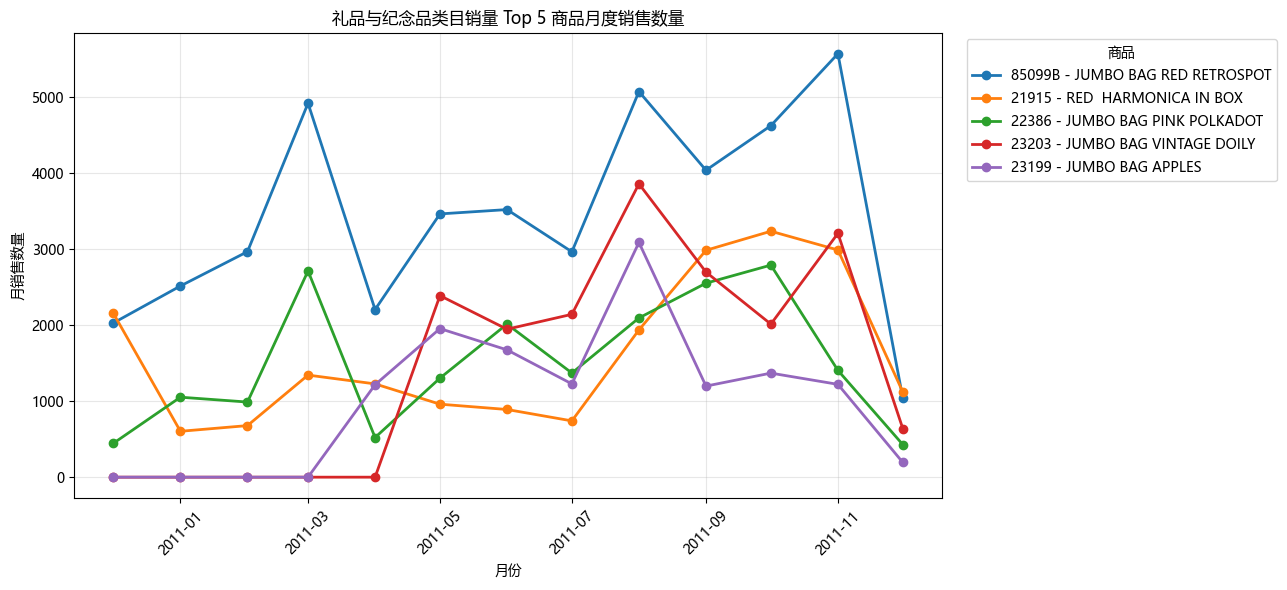

已保存：gift_souvenir_top5_products.xlsx、gift_souvenir_top5_monthly_sales.xlsx


In [9]:
# 礼品与纪念品类目销量 Top 5 商品的月度销售数量分析
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

category_file = './star_products_categorized.xlsx'
retail_file = './Data/Online_Retail_Cleaned.xlsx'
target_category = '礼品与纪念品'
top_n = 5

categorized_products = pd.read_excel(category_file)
required_columns = {'StockCode', '商品类目'}
missing_columns = required_columns.difference(categorized_products.columns)
if missing_columns:
    raise KeyError(f'分类结果缺少字段：{sorted(missing_columns)}')

sales_candidates = ['总销量', '销量', 'Quantity', 'Sales']
sales_column = next(
    (column for column in sales_candidates if column in categorized_products.columns),
    None
)
if sales_column is None:
    raise KeyError(f'未找到销量列，请确认列名为以下之一：{sales_candidates}')

categorized_products['StockCode'] = categorized_products['StockCode'].astype(str).str.strip()
categorized_products[sales_column] = pd.to_numeric(
    categorized_products[sales_column], errors='coerce'
).fillna(0)

target_products = categorized_products[
    categorized_products['商品类目'].eq(target_category)
].copy()
if target_products.empty:
    raise ValueError(f'未找到商品类目：{target_category}')

top_products = (
    target_products.groupby('StockCode', as_index=False)
    .agg(总销量=(sales_column, 'sum'))
    .sort_values('总销量', ascending=False)
    .head(top_n)
    .reset_index(drop=True)
)

if 'Description' in target_products.columns:
    descriptions = target_products[['StockCode', 'Description']].drop_duplicates('StockCode')
else:
    descriptions = top_products[['StockCode']].assign(Description='')
top_products = top_products.merge(descriptions, on='StockCode', how='left')
top_products['商品标签'] = top_products.apply(
    lambda row: f"{row['StockCode']} - {row['Description']}"
    if row['Description'] else row['StockCode'],
    axis=1
)

retail = pd.read_excel(retail_file)
required_retail_columns = {'StockCode', 'Quantity'}
missing_retail_columns = required_retail_columns.difference(retail.columns)
if missing_retail_columns:
    raise KeyError(f'清洗数据缺少字段：{sorted(missing_retail_columns)}')

date_candidates = ['InvoiceDate', '销售日期', '日期', 'Date', '交易日期']
date_column = next((column for column in date_candidates if column in retail.columns), None)
if date_column is None:
    raise KeyError(f'未找到日期列，请确认列名为以下之一：{date_candidates}')

retail['StockCode'] = retail['StockCode'].astype(str).str.strip()
retail['Quantity'] = pd.to_numeric(retail['Quantity'], errors='coerce').fillna(0)
retail[date_column] = pd.to_datetime(retail[date_column], errors='coerce')

monthly_sales = (
    retail.dropna(subset=[date_column])
    .merge(top_products[['StockCode', '商品标签']], on='StockCode', how='inner')
    .assign(月份=lambda data: data[date_column].dt.to_period('M').dt.to_timestamp())
    .groupby(['月份', 'StockCode', '商品标签'], as_index=False)['Quantity']
    .sum()
    .rename(columns={'Quantity': '月销售数量'})
)
if monthly_sales.empty:
    raise ValueError(f'{target_category}类目 Top {top_n} 商品没有可用的月度销售记录')

all_months = pd.date_range(
    monthly_sales['月份'].min(), monthly_sales['月份'].max(), freq='MS'
)
full_index = pd.MultiIndex.from_product(
    [all_months, top_products['StockCode']], names=['月份', 'StockCode']
)
product_labels = top_products.set_index('StockCode')['商品标签']
monthly_sales = (
    monthly_sales.set_index(['月份', 'StockCode'])[['商品标签', '月销售数量']]
    .reindex(full_index)
    .reset_index()
)
monthly_sales['商品标签'] = monthly_sales['StockCode'].map(product_labels)
monthly_sales['月销售数量'] = monthly_sales['月销售数量'].fillna(0)

print(f'{target_category}类目销量 Top {top_n} 商品：')
display(top_products[['StockCode', 'Description', '总销量']])

top_products.to_excel('./gift_souvenir_top5_products.xlsx', index=False)
monthly_sales.to_excel('./gift_souvenir_top5_monthly_sales.xlsx', index=False)

plt.figure(figsize=(13, 6))
for product_code in top_products['StockCode']:
    product_data = monthly_sales[monthly_sales['StockCode'].eq(product_code)]
    plt.plot(
        product_data['月份'],
        product_data['月销售数量'],
        marker='o',
        linewidth=2,
        label=product_labels[product_code]
    )
plt.title(f'{target_category}类目销量 Top {top_n} 商品月度销售数量')
plt.xlabel('月份')
plt.ylabel('月销售数量')
plt.xticks(rotation=45)
plt.legend(title='商品', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('已保存：gift_souvenir_top5_products.xlsx、gift_souvenir_top5_monthly_sales.xlsx')

# 礼品与纪念品类目分析
该类目由购物袋主导，Top5中有4款是JUMBO BAG（大号购物袋），其中蓝色红波点款（85099B）全年领跑并在11月冲上约5500件；整体节奏不是单一圣诞峰，而是“3月—8月—11月”三波备货潮，12月全线下挫。​
## 深度分析
* 红色复古波点购物袋(85099B)是该类目的领头羊。它全年没有出现接近零的月份，基础盘稳定在2000–3500件，并在3月、8月、11月走出三个逐级抬升的峰值。多数月份它的销量相当于第二名的 1.5–2 倍，是典型的“常年即畅销”的核心 SKU，红色波点这一经典复古花色显然最受英国批发客户欢迎。
* 盒装红色口琴(21915)是五款中唯一明确绑定圣诞场景的商品。1–7月它一直在600–1400件徘徊，8月开始爬坡，9–10月放量至约2950–3250并在10月见顶,11月维持约3000，12月骤降至约1100。盒装口琴是典型的圣诞袜礼物与企业批量采购赠品，其“8月启动、10月见顶”的节奏说明礼品类备货比装饰类更早开始。
* 粉色波点购物袋（22386）波动最剧烈：3月冲高约2700后，4月断崖式跌到约500，随后逐月重建，10月回到约2800，11月却又回落至约1400。这种忽高忽低的形态通常意味着它依赖不定期的大批量订单，需求稳定性明显弱于同家族的85099B。
* 复古蕾丝购物袋（23203）是成长性最好的新款。它在2010-12至 2011-03间销量为零，4月首次放量即达约2400，此后除5月短暂回落外一路上扬，8月冲至约4000的类目次高，Q4 仍保持约2000–3000的销售额。上架半年内就逼近老款峰值，属于典型的“上架即放量”的潜力款。
* 苹果图案购物袋（23199）则是AB测试产品，同样是4月前后才出现销量，8月冲到约3000，但9月立即腰斩至约1200，之后一路阴跌，12月只剩约100。两款同期上架的购物袋命运迥异，说明花色选品对这类产品的生命周期影响极大。
## 总结 三波备货潮而非单一圣诞峰
第一波在3月。红色复古波点购物袋(85099B)销售额约​4900、粉色波点购物袋（22386）销售额约​2700。英国的母亲节（4月初）和复活节（4月下旬）都在此时段，3月正是零售端节前采购窗口，购物袋作为节庆打包耗材首当其冲。</br>
第二波在8月，是本类目均上升的期间。​ 除粉色波点购物袋（22386）外，其余四款要么在8月见顶（复古蕾丝购物袋（23203）约3900、苹果图案购物袋（23199）约3000），要么从此启动爬坡（盒装红色口琴(21915)）。这与家居装饰类目“8月备货、10–11 月爆发”不同——购物袋在8月本身就是销售旺季，对应秋季市集、返校季和圣诞备货的双重耗材需求。</br>
第三波在10–11月。​ 红色复古波点购物袋(85099B)11月登顶约5500，盒装红色口琴(21915)10月见顶，粉色波点购物袋（22386）10月回到约2800。这一波才是与圣诞直接挂钩的传统峰值，且主要由核心款与礼品款享受，边缘花色（粉色、苹果款）反而在此期间走弱。
把红色复古波点购物袋(85099B)当作渠道锚点管理。​ 它是唯一全年无近零月份的商品，应设全年安全库存与稳定补货机制，其断供直接影响客户对整个类目的采购黏性。</br>
用“家族思维”管四个购物袋变体。​四款JUMBO BAG共享产品形态与产能，花色即差异化。数据显示花色生命周期差异巨大：红波点长青、蕾丝款快速成长、苹果款一年即衰。建议按季度复盘各花色动销，用同一模具滚动切换图案，让衰退款自然让位给新花色，而不是五种花色平均备货。</br>
备货日历整体前置一个月。​ 本类目8月就是销售高峰，产能与库存必须在 7 月中旬前就位；3 月波峰则要求2月完成春季备货。这与家居装饰类目“8月准备、11月收割”的日历明显不同，两类目的采购与生产计划不能共用一张表。

圣诞节用品类目销量 Top 5 商品：


,StockCode,Description,总销量
0,84879,ASSORTED COLOUR BIRD ORNAMENT,35263
1,22086,PAPER CHAIN KIT 50'S CHRISTMAS,15591
2,22952,60 CAKE CASES VINTAGE CHRISTMAS,14736
3,20668,DISCO BALL CHRISTMAS DECORATION,12618
4,84945,MULTI COLOUR SILVER T-LIGHT HOLDER,10267


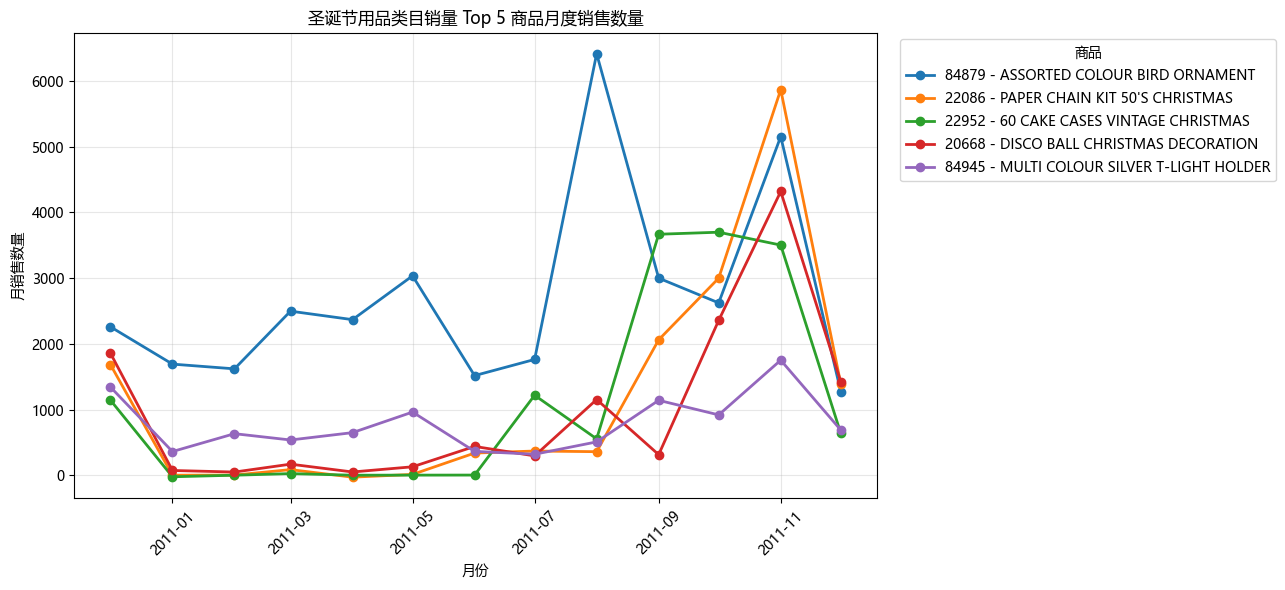

已保存：christmas_top5_products.xlsx、christmas_top5_monthly_sales.xlsx


In [10]:
# 圣诞节用品类目销量 Top 5 商品的月度销售数量分析
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

category_file = './star_products_categorized.xlsx'
retail_file = './Data/Online_Retail_Cleaned.xlsx'
target_category = '圣诞节用品'
top_n = 5

categorized_products = pd.read_excel(category_file)
required_columns = {'StockCode', '商品类目'}
missing_columns = required_columns.difference(categorized_products.columns)
if missing_columns:
    raise KeyError(f'分类结果缺少字段：{sorted(missing_columns)}')

sales_candidates = ['总销量', '销量', 'Quantity', 'Sales']
sales_column = next(
    (column for column in sales_candidates if column in categorized_products.columns),
    None
)
if sales_column is None:
    raise KeyError(f'未找到销量列，请确认列名为以下之一：{sales_candidates}')

categorized_products['StockCode'] = categorized_products['StockCode'].astype(str).str.strip()
categorized_products[sales_column] = pd.to_numeric(
    categorized_products[sales_column], errors='coerce'
).fillna(0)

target_products = categorized_products[
    categorized_products['商品类目'].eq(target_category)
].copy()
if target_products.empty:
    raise ValueError(f'未找到商品类目：{target_category}')

top_products = (
    target_products.groupby('StockCode', as_index=False)
    .agg(总销量=(sales_column, 'sum'))
    .sort_values('总销量', ascending=False)
    .head(top_n)
    .reset_index(drop=True)
)

if 'Description' in target_products.columns:
    descriptions = target_products[['StockCode', 'Description']].drop_duplicates('StockCode')
else:
    descriptions = top_products[['StockCode']].assign(Description='')
top_products = top_products.merge(descriptions, on='StockCode', how='left')
top_products['商品标签'] = top_products.apply(
    lambda row: f"{row['StockCode']} - {row['Description']}"
    if row['Description'] else row['StockCode'],
    axis=1
)

retail = pd.read_excel(retail_file)
required_retail_columns = {'StockCode', 'Quantity'}
missing_retail_columns = required_retail_columns.difference(retail.columns)
if missing_retail_columns:
    raise KeyError(f'清洗数据缺少字段：{sorted(missing_retail_columns)}')

date_candidates = ['InvoiceDate', '销售日期', '日期', 'Date', '交易日期']
date_column = next((column for column in date_candidates if column in retail.columns), None)
if date_column is None:
    raise KeyError(f'未找到日期列，请确认列名为以下之一：{date_candidates}')

retail['StockCode'] = retail['StockCode'].astype(str).str.strip()
retail['Quantity'] = pd.to_numeric(retail['Quantity'], errors='coerce').fillna(0)
retail[date_column] = pd.to_datetime(retail[date_column], errors='coerce')

monthly_sales = (
    retail.dropna(subset=[date_column])
    .merge(top_products[['StockCode', '商品标签']], on='StockCode', how='inner')
    .assign(月份=lambda data: data[date_column].dt.to_period('M').dt.to_timestamp())
    .groupby(['月份', 'StockCode', '商品标签'], as_index=False)['Quantity']
    .sum()
    .rename(columns={'Quantity': '月销售数量'})
)
if monthly_sales.empty:
    raise ValueError(f'{target_category}类目 Top {top_n} 商品没有可用的月度销售记录')

# 补齐没有销售记录的月份，并将其月销量设为 0
all_months = pd.date_range(
    monthly_sales['月份'].min(), monthly_sales['月份'].max(), freq='MS'
)
full_index = pd.MultiIndex.from_product(
    [all_months, top_products['StockCode']], names=['月份', 'StockCode']
)
product_labels = top_products.set_index('StockCode')['商品标签']
monthly_sales = (
    monthly_sales.set_index(['月份', 'StockCode'])[['商品标签', '月销售数量']]
    .reindex(full_index)
    .reset_index()
)
monthly_sales['商品标签'] = monthly_sales['StockCode'].map(product_labels)
monthly_sales['月销售数量'] = monthly_sales['月销售数量'].fillna(0)

print(f'{target_category}类目销量 Top {top_n} 商品：')
display(top_products[['StockCode', 'Description', '总销量']])

top_products.to_excel('./christmas_top5_products.xlsx', index=False)
monthly_sales.to_excel('./christmas_top5_monthly_sales.xlsx', index=False)

plt.figure(figsize=(13, 6))
for product_code in top_products['StockCode']:
    product_data = monthly_sales[monthly_sales['StockCode'].eq(product_code)]
    plt.plot(
        product_data['月份'],
        product_data['月销售数量'],
        marker='o',
        linewidth=2,
        label=product_labels[product_code]
    )
plt.title(f'{target_category}类目销量 Top {top_n} 商品月度销售数量')
plt.xlabel('月份')
plt.ylabel('月销售数量')
plt.xticks(rotation=45)
plt.legend(title='商品', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('已保存：christmas_top5_products.xlsx、christmas_top5_monthly_sales.xlsx')

# 圣诞节用品品类目分析
1–5 月四款商品近乎销量为零，需求从 6 月起爬坡、9–11 月集中释放、12 月骤然退潮；混色小鸟挂饰（84879）是最大例外，它全年有销量并在 8 月就冲出约 6400 件的类目年度最高点，50年代圣诞纸链套装（22086）则是最纯正的圣诞款，11 月以约 5900 件登顶。​这五款商品虽然同属圣诞类目，但“圣诞浓度”差异极大，纸链套装和迪斯科球是纯节日商品，蛋糕纸托绑定圣诞烘焙季，而小鸟挂饰和茶烛灯座实际上具备全年通用属性，这也解释了它们曲线形态的根本不同。
## 深度分析
* 混色小鸟挂饰（84879）是全图的异类，也是年度销量冠军。它 1–7 月就维持 1500–3000 件的动销（3 月约 2500、5 月约 3000 的小高峰），8 月骤然拉出约 6400 的类目年度最高点，9–10 月回落至 2600–3000，11 月再冲约 5150，12 月降至约 1300。它的两个特点值得注意：一是峰值比所有纯圣诞款提前了 2–3 个月，二是淡季不淡。混色小鸟挂饰并非只能挂在圣诞树上，春夏也可做家居、花园装饰，英国批发客户显然在夏季就提前锁定这款“安全牌”商品——8 月巨量本质上是圣诞采购季最早的那批大单。
* 纸链套装（22086）是季节性最纯粹的样本。1–5 月销量几乎贴零（最高仅约 60），6 月才有动静（约 400），9 月爬到约 2050，10 月约 3050，11 月冲顶约 5800，12 月崩落至约 600。纸链是英国家庭圣诞手工装饰的传统项目，零售商等到 10–11 月才敢放量进货——它的曲线形状就是“纯圣诞商品”的定义：冰封半年、两个月赚完全年。
* 蛋糕纸托(22952)走出了独特的“高位平台”：9 月约 3600、10 月约 3600、11 月约 3500，连续三个月站稳 3500 以上，是五款中唯一呈“平台型”而非“尖峰型”的商品。原因在于它是烘焙耗材——英国圣诞蛋糕、迷你水果蛋糕的商业烘焙和零售铺货从 9 月就开始，需求窗口比装饰品更长、更靠前，但单月爆发力不如装饰品。
* 迪斯科球挂饰(20668)是标准的圣诞装饰节奏：1–5 月贴零，6–7 月低位试水（约 400），8 月首个小峰（约 1100）后 9 月回落，10 月放量至约 2350，11 月冲顶约 4300，12 月回落至约 1450。它的 11 月峰值高度居类目第二，是 Q4 销售的中坚力量。
* 茶烛灯座（84945）是类目里的“稳态款”。它全年无一个月归零，淡季维持在 350–1000，5 月还有个约 1000 的小高峰（对应夏季派对、婚礼场景），11 月升至约 1700 的温和峰值。多色银色灯座的通用属性让它成为五款中季节波动最小、但单月爆发力也最弱的商品。
## 总结
冰封期（1–5 月）​：除小鸟挂饰和茶烛灯座外，其余三款销量基本为零。这不是需求疲软，而是 B2B 渠道的理性选择——圣诞商品节后即贬值，批发客户 1 月绝不囤货，哪怕清仓也拉不动曲线。
试探期（6–8 月）​：三款纯圣诞商品从 6 月起出现 300–500 的试探性订单，8 月小鸟挂饰率先爆发约 6500。这是零售商最早一批圣诞采购落地，也是供应商判断当年圣诞热度的首个信号。
放量期（9–10 月）​：蛋糕纸托率先进入 3500+ 平台，纸链、迪斯科球同步爬坡，小鸟挂饰维持 2500–3000。烘焙类先行、装饰类跟进的顺序完全符合节日消费的物理时序——先烤蛋糕，再挂装饰。
冲刺与退潮（11–12 月）​：11 月是类目决胜月，纸链（约 5800）、迪斯科球（约 4300）、小鸟挂饰（约 5100）同时冲顶；12 月则全线暴跌 50%–90%。

# top3商品类目总结

```mermaid
gantt
    title 三类目明星商品“起量→峰值”时间线
    dateFormat  YYYY-MM-DD
    axisFormat  %m月
    section 礼品与纪念品
    波点购物袋（1-2月爬坡→3月首峰）   :b1, 2011-02-01, 2011-04-01
    蕾丝袋（4月上新→8月爆发）         :b2, 2011-04-01, 2011-09-01
    口琴礼盒（8月爬坡→10月见顶）      :b3, 2011-08-01, 2011-11-01
    section 圣诞用品
    纸链/迪斯科球（6月试水→11月登顶） :c1, 2011-06-01, 2011-12-01
    小鸟挂饰（8月提前冲顶）           :c2, 2011-08-01, 2011-09-01
    蛋糕纸托（9-11月平台期）          :c3, 2011-09-01, 2011-12-01
    section 家居装饰
    兔子小夜灯（10月放量→11月登顶）   :a1, 2011-10-01, 2011-12-01

```

## 时间线分析
起量不是均匀分布在四季，而是排成一条“接力链”。​ 冬末 1–2 月礼品类率先爬坡赶 3 月春峰（母亲节、复活节备货）；初夏 6 月圣诞类出现 300–500 件的试探性订单；盛夏 8 月是全局性起量节点——小鸟挂饰冲出年度最高点、蕾丝购物袋放量、口琴开始爬坡；深秋 10 月家居装饰的兔子灯才骤然放量。五个起量点从 1 月到 10 月首尾相接，几乎没有空档。8 月是三类目共同的需求信号验证点。​ 家居装饰在 8–9 月给出 Q4 前奏（PLEASE ONE PERSON METAL SIGN 21181 在 9 月冲 2450），礼品类 8 月出现双款爆发，圣诞类 8 月落下最早一批圣诞大单。8 月数据同比走高，就可以放心为 Q4 加码投产；反之则是压缩风险的第一时间点。

```mermaid
gantt
    title B2B 上新节奏日历（英国市场 · 三类目数据提炼）
    dateFormat  YYYY-MM-DD
    axisFormat  %m月

    section 春季窗口
    春品上架与首批铺货           :p1, 2011-01-01, 2011-02-28
    3月首峰（春节庆备货截止）     :milestone, m1, 2011-03-01, 0d

    section 黄金上新窗
    新品上架·借力8月验证潮        :active, p2, 2011-04-01, 2011-05-31
    圣诞品上架最后期限（6月底）    :crit, p3, 2011-06-01, 2011-06-30

    section 验证与加码
    8月销量验证·加码或清退决策     :p4, 2011-08-01, 2011-08-31

    section Q4 收割期
    核心款补足安全库存            :p5, 2011-10-01, 2011-11-30
    12月清仓·让路次年春品         :p6, 2011-12-01, 2011-12-25
```

## 上新时间线分析
1–2 月：春季品铺货期。​ 礼品类 3 月首峰前 1–2 个月是最后铺货窗口，春季节庆商品（贺礼、包装耗材）必须在此期间完成上架和首批铺货。<br>
4–6 月：全年黄金上新窗。​ 数据给出最有说服力的证据是两款同期上架的购物袋——蕾丝款 4 月上架即起量、8 月冲至类目次高；苹果款同样 4 月进场、8 月短暂爆发后一年内退场。这说明 4–5 月上新可以完整借力“8 月验证潮 + Q4 收割季”，4 个月就能完成一次新品从冷启动到爆发的全周期检验，哪怕失败也能在 8 月及时止损，换新花色再战。圣诞类商品则必须赶在 6 月起量前上架，6 月底是上架的最后期限——错过这个窗口，就错过整个销售季，再好的商品也只能等明年。<br>
8 月：验证与加码决策点。​ 8 月销量是 Q4 的先行指标。此时距离峰值季还有 2–3 个月调整窗口：表现好的新品加大投产、追加渠道；表现平淡的果断清退，把产能和资金让给已被验证的核心款。<br>
10 月起：只补货，不上新。​ 兔子小夜灯 10 月起量、11 月登顶的形态说明，深秋的爆发属于“已铺货商品的收割期”，此时新上架的商品没有时间完成批发渠道的渗透，强行上新只会占用旺季资源。这个阶段的正确动作是为核心款补足安全库存，并在 12 月回落后立即启动清仓，为次年 1–2 月的春品让出渠道和资金。<br>
